# renquant_103 — Adaptive Regime Multi-Stock Strategy

**New vs 102**: 3-layer regime detection (Hurst + CUSUM + GMM), regime-conditional entry, relative-strength ranking, correlation-aware selection, earnings filter, defensive tickers (GLD/TLT/XLV/XLU).

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap

import common
from common.data import fetch_ohlcv
from common.indicators import (
    compute_indicators,
    compute_hurst, rolling_hurst,
    compute_cusum, rolling_cusum,
    build_gmm_features, RegimeGMM,
)
from common.models import create_model
from common.config import load_strategy_config
from common.portfolio import portfolio_stats

STRATEGY   = "renquant_103"
STRATEGY_DIR = ROOT / "backtesting" / STRATEGY
CONFIG     = load_strategy_config(STRATEGY_DIR / "strategy_config.json")
WATCHLIST  = CONFIG["watchlist"]
DEFENSIVE  = set(CONFIG.get("defensive_tickers", []))
SECTOR_ETF = CONFIG.get("sector_etf_map", {})

print(f"Strategy : {STRATEGY}")
print(f"Watchlist: {WATCHLIST}")
print(f"Defensive: {sorted(DEFENSIVE)}")


Strategy : renquant_103
Watchlist: ['TSLA', 'AMZN', 'GOOG', 'MSFT', 'AMD', 'NFLX', 'CRM', 'PLTR', 'UBER', 'NVDA', 'META', 'AAPL', 'JPM', 'UNH', 'XOM', 'CAT', 'BA', 'XLE', 'XLF', 'LLY', 'GLD', 'TLT', 'XLV', 'XLU']
Defensive: ['GLD', 'TLT', 'XLU', 'XLV']


## 1  Fetch OHLCV data

In [2]:
from common.config import load_strategy_config

SAMPLE_START = CONFIG["sample_start"]
SAMPLE_END   = CONFIG["sample_end"]

# All unique tickers we need: watchlist + sector ETFs + SPY
all_tickers = sorted(set(WATCHLIST) | set(SECTOR_ETF.values()) | {"SPY"})
print(f"Fetching {len(all_tickers)} tickers from {SAMPLE_START} to {SAMPLE_END}...")

ohlcv = {}
for ticker in all_tickers:
    try:
        df = fetch_ohlcv(ticker, start=SAMPLE_START, end=SAMPLE_END)
        if df is not None and not df.empty:
            ohlcv[ticker] = df
            print(f"  {ticker}: {len(df)} rows")
        else:
            print(f"  {ticker}: EMPTY")
    except Exception as e:
        print(f"  {ticker}: ERROR — {e}")

print(f"\nLoaded {len(ohlcv)} / {len(all_tickers)} tickers.")
spy_df = ohlcv["SPY"]


Fetching 27 tickers from 2016-01-01 to 2026-06-30...


  AAPL: 2582 rows


  AMD: 2582 rows


  AMZN: 2582 rows


  BA: 2582 rows


...

  XLI: 2582 rows


  XLK: 2582 rows


  XLU: 2582 rows


  XLV: 2582 rows


  XOM: 2582 rows

Loaded 27 / 27 tickers.


## 2  SPY Regime Analysis — 3-Layer Detection

In [3]:
# ── Layer 1: Rolling Hurst exponent ──────────────────────────────────────────
spy_returns = spy_df["close"].pct_change().dropna()
HURST_WINDOW = CONFIG["regime"]["hurst_window"]  # 63

hurst_series = rolling_hurst(spy_returns, window=HURST_WINDOW)
hurst_series = hurst_series.dropna()

# ── Layer 2: Rolling CUSUM changepoints ──────────────────────────────────────
cusum_series = rolling_cusum(
    spy_returns,
    window    = CONFIG["regime"]["cusum_lookback"],
    threshold = CONFIG["regime"]["cusum_threshold"],
    drift     = CONFIG["regime"]["cusum_drift"],
)

changepoint_dates = cusum_series[cusum_series].index
print(f"CUSUM detected {len(changepoint_dates)} changepoints")
print(f"Hurst range: {hurst_series.min():.3f} – {hurst_series.max():.3f}  "
      f"(mean={hurst_series.mean():.3f})")


CUSUM detected 264 changepoints
Hurst range: 0.472 – 0.875  (mean=0.702)


In [4]:
# ── Layer 3: Train GMM on SPY features ───────────────────────────────────────
gmm_features = build_gmm_features(spy_df, vol_window=20, hurst_window=HURST_WINDOW)

gmm = RegimeGMM(n_components=3, random_state=42, n_init=10)
gmm.fit(gmm_features)

print(f"GMM cluster labels (auto-assigned): {gmm.cluster_labels}")
print(f"GMM weights: {np.round(gmm._gmm.weights_, 3)}")

regime_labels, regime_probs = gmm.predict(gmm_features)
print(f"\nRegime distribution:")
print(regime_labels.value_counts())


GMM cluster labels (auto-assigned): ['BULL_CALM', 'BEAR', 'BULL_VOLATILE']
GMM weights: [0.481 0.041 0.478]

Regime distribution:
BULL_CALM        1312
BULL_VOLATILE    1158
BEAR               86
Name: count, dtype: int64


In [5]:
# ── Combine layers into final daily regime ────────────────────────────────────
BULL_CALM, BULL_VOLATILE, CHOPPY, BEAR = "BULL_CALM", "BULL_VOLATILE", "CHOPPY", "BEAR"

common_idx = hurst_series.index.intersection(regime_labels.index)
final_regime = pd.Series(index=common_idx, dtype=str)

for date in common_idx:
    h = hurst_series.loc[date]
    gmm_r = regime_labels.loc[date]
    gmm_bear_p = regime_probs.loc[date].get(BEAR, 0.0)

    # Layer 1 → base
    if h > 0.55:
        base = BULL_CALM
    elif h < 0.45:
        base = CHOPPY
    else:
        base = None  # ambiguous

    # GMM BEAR override
    if gmm_bear_p > 0.5:
        final_regime.loc[date] = BEAR
    elif base is None:
        final_regime.loc[date] = gmm_r if gmm_r != BEAR else BULL_VOLATILE
    else:
        final_regime.loc[date] = base

print("Final regime distribution:")
print(final_regime.value_counts())

# Save GMM artifact for LEAN
gmm_path = STRATEGY_DIR / "spy-gmm-regime.json"
gmm.save(gmm_path)
print(f"\nGMM artifact saved → {gmm_path}")


Final regime distribution:
BULL_CALM        2421
BEAR               86
BULL_VOLATILE      12
Name: count, dtype: int64

GMM artifact saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/spy-gmm-regime.json


## 3  Regime Charts

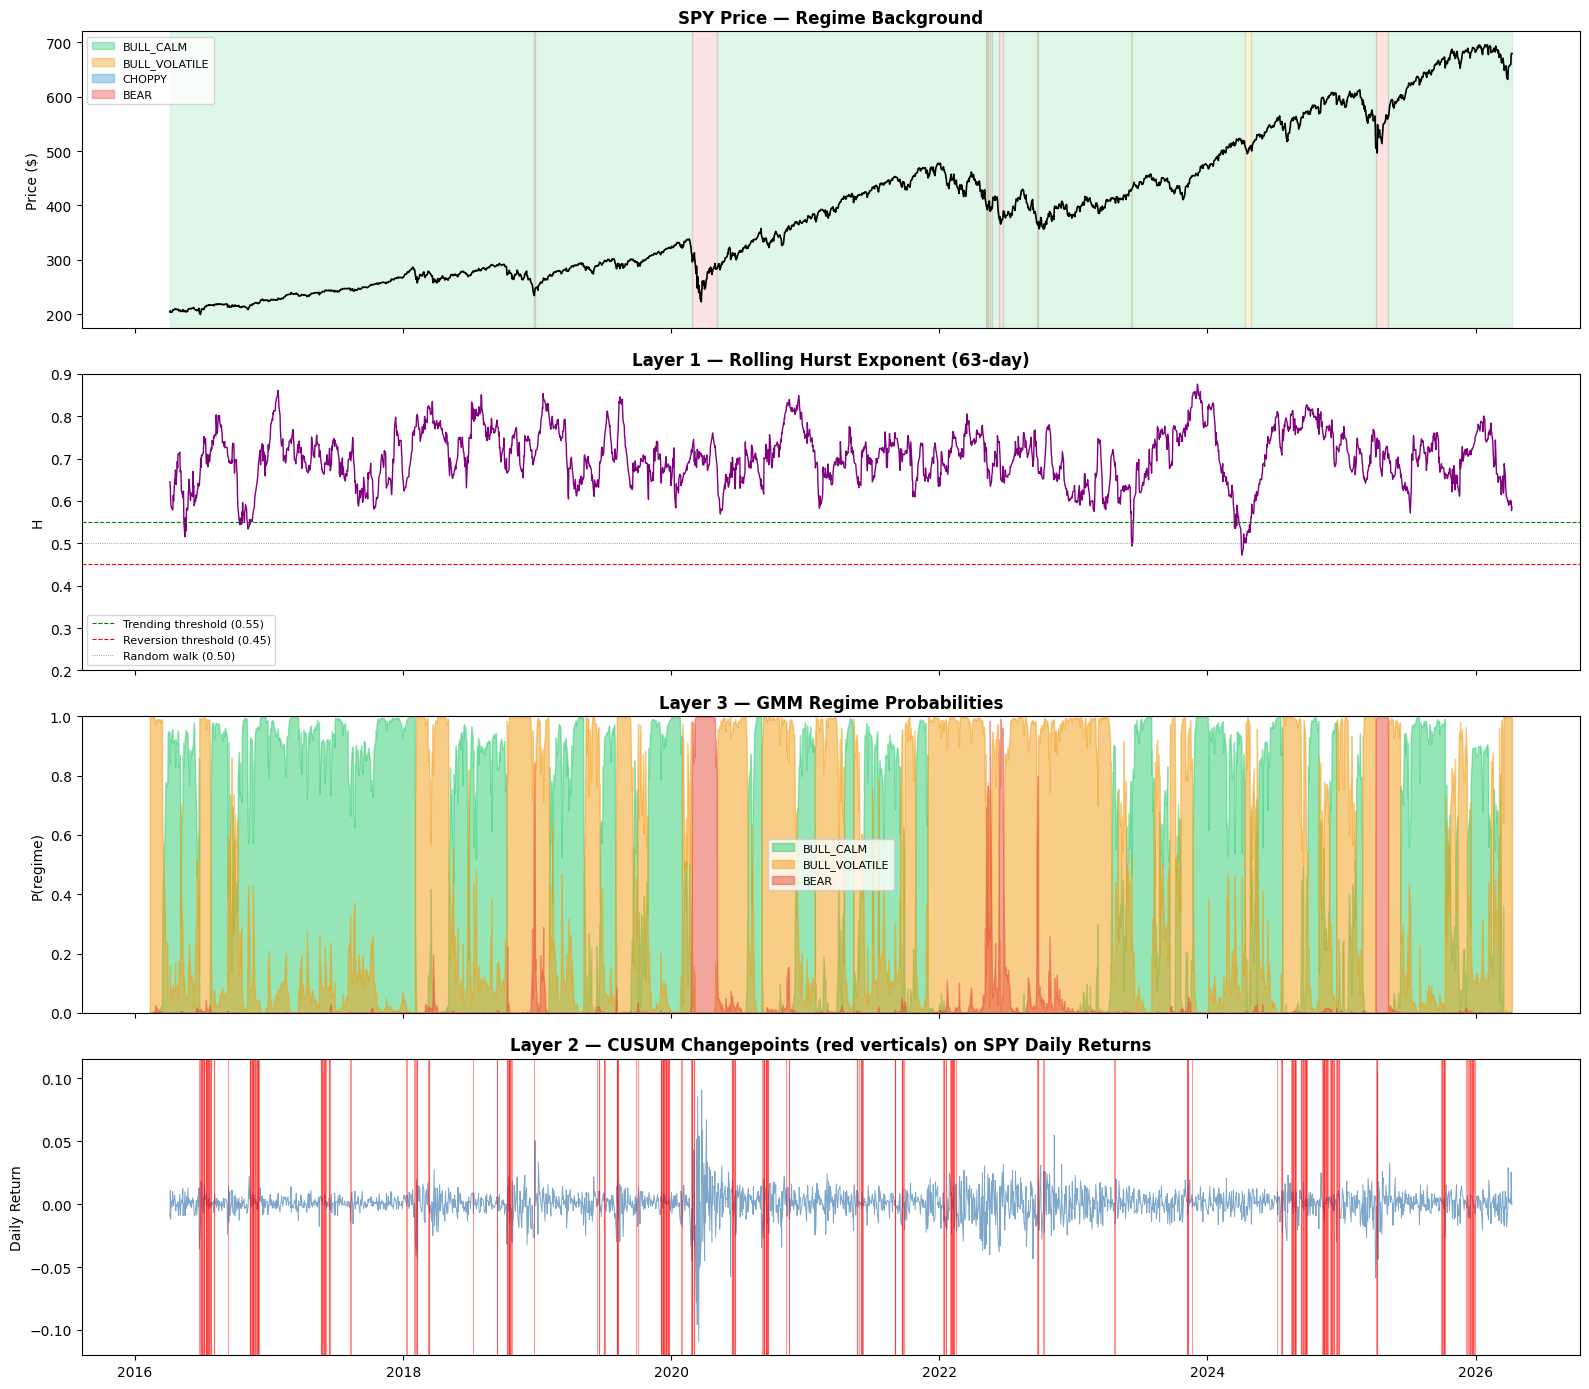

Chart saved → regime_analysis.png


In [6]:
REGIME_COLORS = {
    BULL_CALM:     "#2ecc71",   # green
    BULL_VOLATILE: "#f39c12",   # orange
    CHOPPY:        "#3498db",   # blue
    BEAR:          "#e74c3c",   # red
}

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

spy_close = spy_df["close"].reindex(final_regime.index)

# Panel 1: SPY price with regime background shading
ax = axes[0]
ax.plot(spy_close.index, spy_close.values, color="black", lw=1.2, label="SPY Close")
prev_regime = None
start_date  = None
for date in final_regime.index:
    r = final_regime.loc[date]
    if r != prev_regime:
        if prev_regime is not None:
            ax.axvspan(start_date, date, alpha=0.15,
                       color=REGIME_COLORS.get(prev_regime, "grey"))
        prev_regime = r
        start_date  = date
if prev_regime:
    ax.axvspan(start_date, final_regime.index[-1], alpha=0.15,
               color=REGIME_COLORS.get(prev_regime, "grey"))
patches = [mpatches.Patch(color=c, alpha=0.4, label=r)
           for r, c in REGIME_COLORS.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8)
ax.set_title("SPY Price — Regime Background", fontweight="bold")
ax.set_ylabel("Price ($)")

# Panel 2: Hurst exponent
ax = axes[1]
ax.plot(hurst_series.index, hurst_series.values, color="purple", lw=1.0)
ax.axhline(0.55, color="green",  ls="--", lw=0.8, label="Trending threshold (0.55)")
ax.axhline(0.45, color="red",    ls="--", lw=0.8, label="Reversion threshold (0.45)")
ax.axhline(0.50, color="grey",   ls=":",  lw=0.6, label="Random walk (0.50)")
ax.set_ylim(0.2, 0.9)
ax.set_title("Layer 1 — Rolling Hurst Exponent (63-day)", fontweight="bold")
ax.set_ylabel("H")
ax.legend(fontsize=8)

# Panel 3: GMM regime probabilities
ax = axes[2]
for regime, color in REGIME_COLORS.items():
    if regime in regime_probs.columns:
        ax.fill_between(regime_probs.index, regime_probs[regime],
                        alpha=0.5, label=regime, color=color)
ax.set_ylim(0, 1)
ax.set_title("Layer 3 — GMM Regime Probabilities", fontweight="bold")
ax.set_ylabel("P(regime)")
ax.legend(fontsize=8)

# Panel 4: CUSUM changepoints on SPY returns
ax = axes[3]
ax.plot(spy_returns.reindex(final_regime.index).index,
        spy_returns.reindex(final_regime.index).values,
        color="steelblue", lw=0.7, alpha=0.7)
for d in changepoint_dates:
    if d in final_regime.index:
        ax.axvline(d, color="red", alpha=0.4, lw=0.8)
ax.set_title("Layer 2 — CUSUM Changepoints (red verticals) on SPY Daily Returns",
             fontweight="bold")
ax.set_ylabel("Daily Return")

plt.tight_layout()
plt.savefig(STRATEGY_DIR / "regime_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → regime_analysis.png")


## 4  Build Per-Symbol Feature Frames

In [7]:
INDICATOR_SPEC = CONFIG["indicator_spec"]
MODEL_PARAMS   = CONFIG["model_params"]
FEATURE_COLS   = MODEL_PARAMS["feature_columns"]
LOOKAHEAD      = MODEL_PARAMS["lookahead"]     # 5 days
THRESHOLD      = MODEL_PARAMS["threshold"]     # 0.03 = 3%

spy_ind = compute_indicators(ohlcv["SPY"], INDICATOR_SPEC)

# Precompute SPY regime context columns (added to each stock frame)
spy_rets_all  = ohlcv["SPY"]["close"].pct_change()
spy_adx_all   = spy_ind["adx"] if "adx" in spy_ind.columns else pd.Series(25.0, index=spy_ind.index)
spy_ema50_all = ohlcv["SPY"]["close"].ewm(span=50, adjust=False).mean()
spy_trend_all = ohlcv["SPY"]["close"] / spy_ema50_all

feature_frames = {}
ratio_features = {"rsi", "adx"}
diff_features  = {"macd_hist", "cci", "bbp", "williams_r", "obv_slope"}

for ticker in WATCHLIST:
    if ticker not in ohlcv:
        print(f"  {ticker}: no data, skipping")
        continue
    try:
        stock_ind  = compute_indicators(ohlcv[ticker], INDICATOR_SPEC)
        common_idx = stock_ind.index.intersection(spy_ind.index)

        s = stock_ind.loc[common_idx].copy()
        p = spy_ind.loc[common_idx].copy()

        result = pd.DataFrame(index=common_idx)

        # Relative close: stock / SPY * 100 — labels measure outperformance vs SPY.
        # This prevents bull-market always-buy bias (raw returns are nearly always positive).
        spy_close_aligned = ohlcv["SPY"]["close"].reindex(common_idx)
        result["close"] = s["close"] / spy_close_aligned.replace(0, np.nan) * 100

        for col in ratio_features:
            if col in s.columns and col in p.columns:
                result[col] = s[col] / p[col].replace(0, np.nan)
        for col in diff_features:
            if col in s.columns and col in p.columns:
                result[col] = s[col] - p[col]

        # Trend features
        close  = s["close"]
        ema50  = close.ewm(span=50, adjust=False).mean()
        ema200 = close.ewm(span=200, adjust=False).mean()
        result["trend"]      = close / ema50
        result["trend_long"] = close / ema200
        spy_close_c = p["close"]
        rel_price   = close / spy_close_c
        result["rel_mom_20d"] = rel_price.pct_change(20)
        result["rel_mom_60d"] = rel_price.pct_change(60)

        # Regime context (103-only features)
        spy_rets_c = spy_rets_all.reindex(common_idx)
        result["spy_realized_vol"] = spy_rets_c.rolling(20).std() * np.sqrt(252)
        result["spy_adx"]          = spy_adx_all.reindex(common_idx)
        result["spy_trend"]        = spy_trend_all.reindex(common_idx)
        result["hurst_proxy"]      = spy_rets_c.rolling(20).apply(
            lambda x: np.corrcoef(x[:-1], x[1:])[0, 1] if len(x) > 2 else 0.0, raw=True)

        # Relative forward return: stock outperformance vs SPY over LOOKAHEAD days.
        # Label +1 = stock beats SPY by THRESHOLD, -1 = underperforms, 0 = neutral.
        stock_fwd = ohlcv[ticker]["close"].pct_change(LOOKAHEAD).shift(-LOOKAHEAD)
        spy_fwd   = ohlcv["SPY"]["close"].pct_change(LOOKAHEAD).shift(-LOOKAHEAD)
        rel_fwd   = stock_fwd - spy_fwd.reindex(stock_fwd.index)
        result["fwd_return"] = rel_fwd.reindex(common_idx)
        result["label"] = np.where(result["fwd_return"] >  THRESHOLD,  1,
                          np.where(result["fwd_return"] < -THRESHOLD, -1, 0))

        result = result.dropna()
        feature_frames[ticker] = result
        lv = result["label"].value_counts().to_dict()
        print(f"  {ticker}: {len(result)} rows  "
              f"buy={lv.get(1,0)}  sell={lv.get(-1,0)}  hold={lv.get(0,0)}")
    except Exception as e:
        print(f"  {ticker}: ERROR — {e}")

print(f"\nBuilt frames for {len(feature_frames)} / {len(WATCHLIST)} symbols.")


  TSLA: 2517 rows  buy=797  sell=725  hold=995
  AMZN: 2517 rows  buy=418  sell=337  hold=1762
  GOOG: 2517 rows  buy=303  sell=262  hold=1952


  MSFT: 2517 rows  buy=206  sell=165  hold=2146


  AMD: 2517 rows  buy=833  sell=682  hold=1002
  NFLX: 2517 rows  buy=577  sell=485  hold=1455
  CRM: 2517 rows  buy=389  sell=429  hold=1699
  PLTR: 1323 rows  buy=464  sell=407  hold=452


  UBER: 1674 rows  buy=440  sell=459  hold=775


  NVDA: 2517 rows  buy=792  sell=499  hold=1226
  META: 2517 rows  buy=457  sell=400  hold=1660
  AAPL: 2517 rows  buy=348  sell=269  hold=1900


  JPM: 2517 rows  buy=283  sell=239  hold=1995
  UNH: 2517 rows  buy=380  sell=345  hold=1792


  XOM: 2517 rows  buy=362  sell=405  hold=1750
  CAT: 2517 rows  buy=446  sell=329  hold=1742
  BA: 2517 rows  buy=508  sell=504  hold=1505


  XLE: 2517 rows  buy=382  sell=381  hold=1754
  XLF: 2517 rows  buy=101  sell=82  hold=2334


  LLY: 2517 rows  buy=464  sell=379  hold=1674
  GLD: 2517 rows  buy=316  sell=306  hold=1895


  TLT: 2517 rows  buy=261  sell=361  hold=1895
  XLV: 2517 rows  buy=84  sell=100  hold=2333
  XLU: 2517 rows  buy=207  sell=262  hold=2048

Built frames for 24 / 24 symbols.


## 5  Train Per-Symbol Models (3-approach tournament)

In [8]:
from common.models import create_model
from common.portfolio import portfolio_stats
from common.tax import compute_after_tax_pnl

TRAIN_SPLIT   = CONFIG["train_split"]
BUY_THR       = MODEL_PARAMS["buy_threshold"]
SELL_THR      = MODEL_PARAMS["sell_threshold"]
BAGS          = MODEL_PARAMS["bags"]
LEAF_SIZE     = MODEL_PARAMS["leaf_size"]
ST_RATE       = CONFIG["tax"]["short_term_rate"]
LT_RATE       = CONFIG["tax"]["long_term_rate"]
LT_THRESH     = CONFIG["tax"]["long_term_threshold_days"]
SHARPE_FLOOR  = 0.8

results = {}

def oos_sharpe(prices, signals, tax_st=ST_RATE, tax_lt=LT_RATE, lt_days=LT_THRESH):
    """Annualised Sharpe on OOS signals (direct return calculation)."""
    try:
        prices = prices.dropna()
        if len(prices) < 20:
            return 0.0
        sigs = signals.reindex(prices.index).ffill().fillna(0).clip(0, 1)
        daily_ret = prices.pct_change().fillna(0)
        strat_ret = daily_ret * sigs.shift(1).fillna(0)
        std = strat_ret.std()
        if std == 0:
            return 0.0
        return float(strat_ret.mean() / std * np.sqrt(252))
    except Exception as e:
        print(f"    oos_sharpe error: {e}")
        return -99

for ticker in WATCHLIST:
    if ticker not in feature_frames:
        print(f"{ticker}: no feature frame, skipping")
        continue
    df = feature_frames[ticker]
    # Row-count split (70/30): last 30% is always OOS.
    # Seeded per ticker so results are reproducible across daily runs.
    split = int(len(df) * TRAIN_SPLIT)
    if split < 60 or len(df) - split < 30:
        print(f"{ticker}: insufficient data ({len(df)} rows), skipping")
        continue
    train_df = df.iloc[:split]
    oos_df   = df.iloc[split:]
    prices   = ohlcv[ticker]["close"].reindex(oos_df.index)

    best_sharpe = -99
    best_model  = None
    best_name   = None
    best_sigs   = None

    # ── Approach 1: Classification (BagLearner / RTLearner) ──
    try:
        _clf_seed = abs(hash(ticker)) % (2**32)
        np.random.seed(_clf_seed)          # deterministic per-ticker classification
        clf = create_model("classification", feature_columns=FEATURE_COLS,
                           lookahead=LOOKAHEAD, threshold=THRESHOLD,
                           leaf_size=LEAF_SIZE, bags=BAGS,
                           buy_threshold=BUY_THR, sell_threshold=SELL_THR)
        clf.train(train_df)
        raw_sigs = clf.predict_bulk(oos_df)
        sigs = raw_sigs.map({"buy": 1, "hold": 0, "sell": -1}).reindex(oos_df.index)
        sh   = oos_sharpe(prices, sigs)
        print(f"  {ticker} Classification OOS Sharpe: {sh:.3f}")
        if sh > best_sharpe:
            best_sharpe, best_model, best_name, best_sigs = sh, clf, "Classification", sigs
    except Exception as e:
        print(f"  {ticker} Classification error: {e}")

    # ── Approach 2: Q-Learning ──
    try:
        import random as _random
        _seed = abs(hash(ticker)) % (2**32)
        _random.seed(_seed)        # deterministic per-ticker QL training
        np.random.seed(_seed)
        ql = create_model("qlearning", feature_columns=FEATURE_COLS[:5])
        ql.train(train_df)
        raw_sigs = ql.predict_bulk(oos_df)
        sigs = raw_sigs.map({"buy": 1, "hold": 0, "sell": -1}).reindex(oos_df.index)
        sh   = oos_sharpe(prices, sigs)
        print(f"  {ticker} QLearning    OOS Sharpe: {sh:.3f}")
        if sh > best_sharpe:
            best_sharpe, best_model, best_name, best_sigs = sh, ql, "QLearning", sigs
    except Exception as e:
        print(f"  {ticker} QLearning error: {e}")

    # ── Approach 3: Manual baseline ──
    try:
        manual = create_model("manual", buy_threshold=2, sell_threshold=-2)
        manual.train(train_df)
        raw_sigs = manual.predict_bulk(oos_df)
        sigs = raw_sigs.map({"buy": 1, "hold": 0, "sell": -1}).reindex(oos_df.index)
        sh   = oos_sharpe(prices, sigs)
        print(f"  {ticker} Manual       OOS Sharpe: {sh:.3f}")
        if sh > best_sharpe:
            best_sharpe, best_model, best_name, best_sigs = sh, manual, "Manual", sigs
    except Exception as e:
        print(f"  {ticker} Manual error: {e}")

    results[ticker] = {
        "sharpe":        best_sharpe,
        "best_approach": best_name,
        "model":         best_model,
        "oos_signals":   best_sigs,
        "oos_prices":    prices,
        "train_rows":    split,
        "oos_rows":      len(oos_df),
        "passes_floor":  best_sharpe >= SHARPE_FLOOR,
    }
    status = "✓ PASS" if best_sharpe >= SHARPE_FLOOR else "✗ FAIL (no model exported)"
    print(f"  → WINNER: {best_name}  Sharpe={best_sharpe:.3f}  {status}\n")


  TSLA Classification OOS Sharpe: 0.459


  TSLA QLearning    OOS Sharpe: 0.255
  TSLA Manual       OOS Sharpe: 0.883
  → WINNER: Manual  Sharpe=0.883  ✓ PASS

  AMZN Classification OOS Sharpe: 0.591


  AMZN QLearning    OOS Sharpe: 0.877
  AMZN Manual       OOS Sharpe: 0.852
  → WINNER: QLearning  Sharpe=0.877  ✓ PASS

  GOOG Classification OOS Sharpe: -0.492


  GOOG QLearning    OOS Sharpe: 1.289
  GOOG Manual       OOS Sharpe: 0.223
  → WINNER: QLearning  Sharpe=1.289  ✓ PASS

  MSFT Classification OOS Sharpe: -0.807


  MSFT QLearning    OOS Sharpe: 0.490
  MSFT Manual       OOS Sharpe: 0.401
  → WINNER: QLearning  Sharpe=0.490  ✗ FAIL (no model exported)

  AMD Classification OOS Sharpe: 0.740


...

  LLY QLearning    OOS Sharpe: 1.019
  LLY Manual       OOS Sharpe: 0.141
  → WINNER: QLearning  Sharpe=1.019  ✓ PASS

  GLD Classification OOS Sharpe: -1.217


  GLD QLearning    OOS Sharpe: 1.069
  GLD Manual       OOS Sharpe: 0.295
  → WINNER: QLearning  Sharpe=1.069  ✓ PASS

  TLT Classification OOS Sharpe: 0.175


  TLT QLearning    OOS Sharpe: -0.570
  TLT Manual       OOS Sharpe: -0.367
  → WINNER: Classification  Sharpe=0.175  ✗ FAIL (no model exported)

  XLV Classification OOS Sharpe: 0.000


  XLV QLearning    OOS Sharpe: 0.421
  XLV Manual       OOS Sharpe: -0.394
  → WINNER: QLearning  Sharpe=0.421  ✗ FAIL (no model exported)

  XLU Classification OOS Sharpe: 0.039


  XLU QLearning    OOS Sharpe: 0.703
  XLU Manual       OOS Sharpe: 0.253
  → WINNER: QLearning  Sharpe=0.703  ✗ FAIL (no model exported)



## 6  Export Models to LEAN artifact directory

In [9]:
from datetime import date as today_date

TODAY = str(today_date.today())
exported, skipped_floor = [], []

for ticker, r in results.items():
    if not r["passes_floor"]:
        skipped_floor.append(ticker)
        continue
    sym_dir = STRATEGY_DIR / "models" / ticker
    sym_dir.mkdir(parents=True, exist_ok=True)
    r["model"].save(sym_dir, model_name=ticker)

    # Patch metadata with 103-specific fields
    meta_path = sym_dir / f"{ticker}-policy-metadata.json"
    if meta_path.exists():
        with meta_path.open() as f:
            meta = json.load(f)
        meta["trained_date"]   = TODAY
        meta["best_approach"]  = r["best_approach"]
        meta["sharpe"]         = round(r["sharpe"], 4)
        meta["lookahead"]      = LOOKAHEAD
        meta["strategy"]       = STRATEGY
        with meta_path.open("w") as f:
            json.dump(meta, f, indent=2)
    exported.append(ticker)

print(f"Exported : {sorted(exported)}")
print(f"Skipped (below Sharpe floor {SHARPE_FLOOR}): {sorted(skipped_floor)}")


Exported : ['AAPL', 'AMZN', 'CAT', 'GLD', 'GOOG', 'JPM', 'LLY', 'META', 'NFLX', 'NVDA', 'PLTR', 'TSLA', 'XLF', 'XOM']
Skipped (below Sharpe floor 0.8): ['AMD', 'BA', 'CRM', 'MSFT', 'TLT', 'UBER', 'UNH', 'XLE', 'XLU', 'XLV']


## 7  Correlation Matrix — Watchlist Diversification

Correlation matrix saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/watchlist-correlation.json


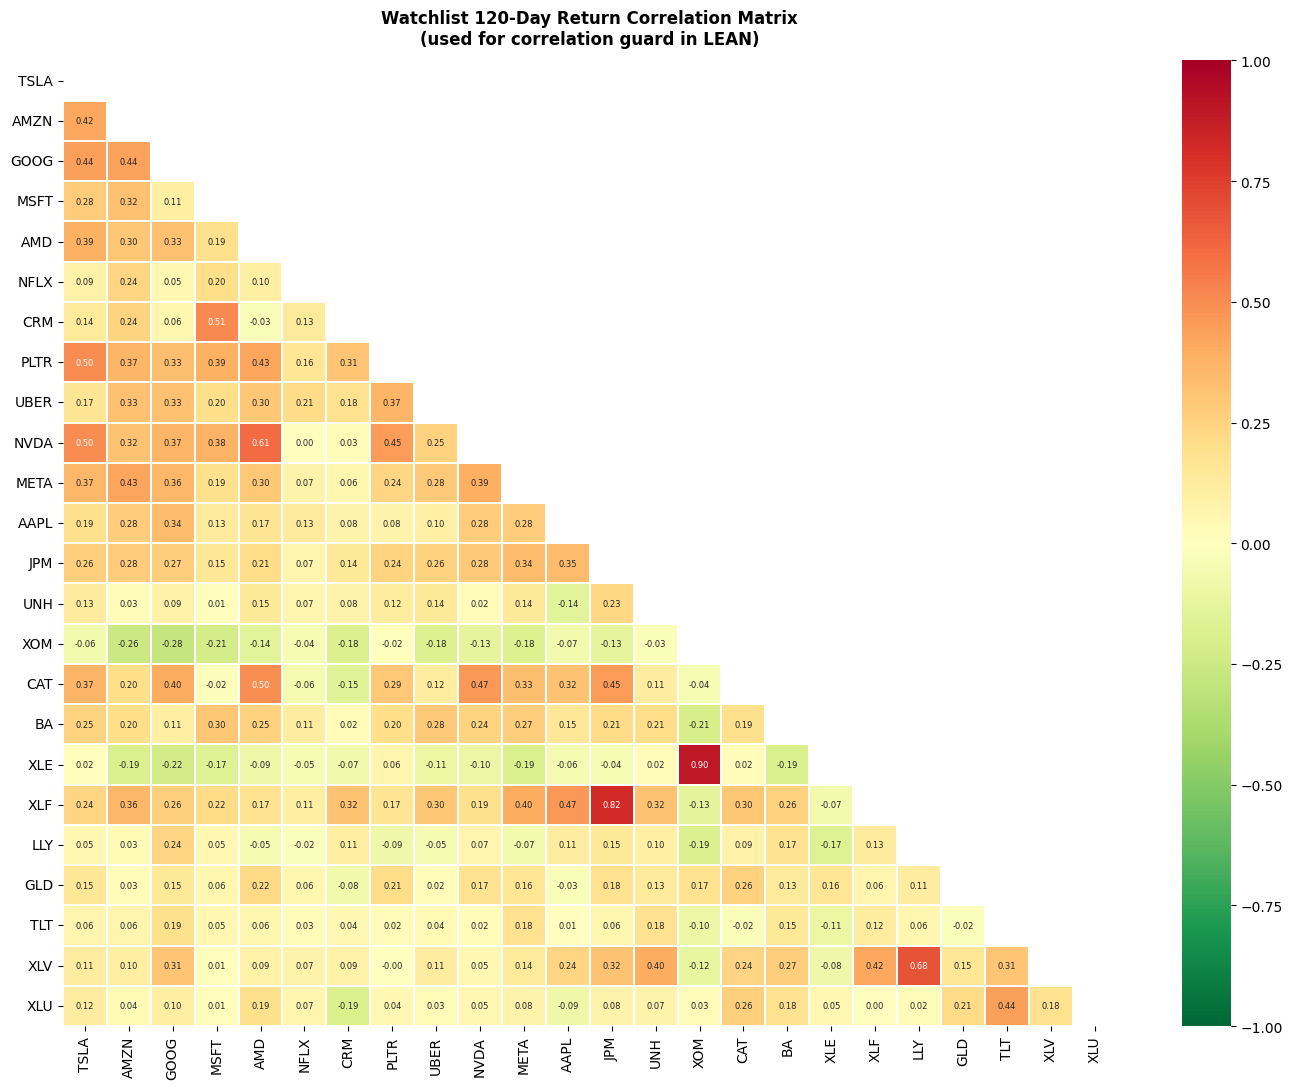

Heatmap saved → correlation_heatmap.png


In [10]:
# Compute 60-day rolling correlation on OOS period (use full sample for the artifact)
close_df = pd.DataFrame({
    t: ohlcv[t]["close"] for t in WATCHLIST if t in ohlcv
})
ret_df = close_df.pct_change().dropna()

# Use last 120 days for the artifact (representative of current correlations)
corr_matrix = ret_df.tail(120).corr()

# Save as JSON for LEAN
corr_dict = {}
for ticker in corr_matrix.index:
    corr_dict[ticker] = {
        other: round(float(corr_matrix.loc[ticker, other]), 4)
        for other in corr_matrix.columns
    }
corr_path = STRATEGY_DIR / "watchlist-correlation.json"
corr_path.write_text(json.dumps(corr_dict, indent=2))
print(f"Correlation matrix saved → {corr_path}")

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            annot_kws={"size": 6})
ax.set_title("Watchlist 120-Day Return Correlation Matrix\n(used for correlation guard in LEAN)",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(STRATEGY_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved → correlation_heatmap.png")


## 8  Model Summary Table

            Sector Defensive        Approach OOS Sharpe Exported  OOS rows
Ticker                                                                    
TSLA          tech                    Manual      0.883        ✓       756
AMZN          tech                 QLearning      0.877        ✓       756
GOOG          tech                 QLearning      1.289        ✓       756
MSFT          tech                 QLearning      0.490        ✗       756
AMD           tech            Classification      0.740        ✗       756
NFLX          tech                 QLearning      1.375        ✓       756
CRM           tech            Classification      0.345        ✗       756
PLTR          tech                 QLearning      1.685        ✓       397
UBER          tech            Classification      0.755        ✗       503
NVDA          tech                    Manual      1.583        ✓       756
META          tech                 QLearning      1.247        ✓       756
AAPL          tech       

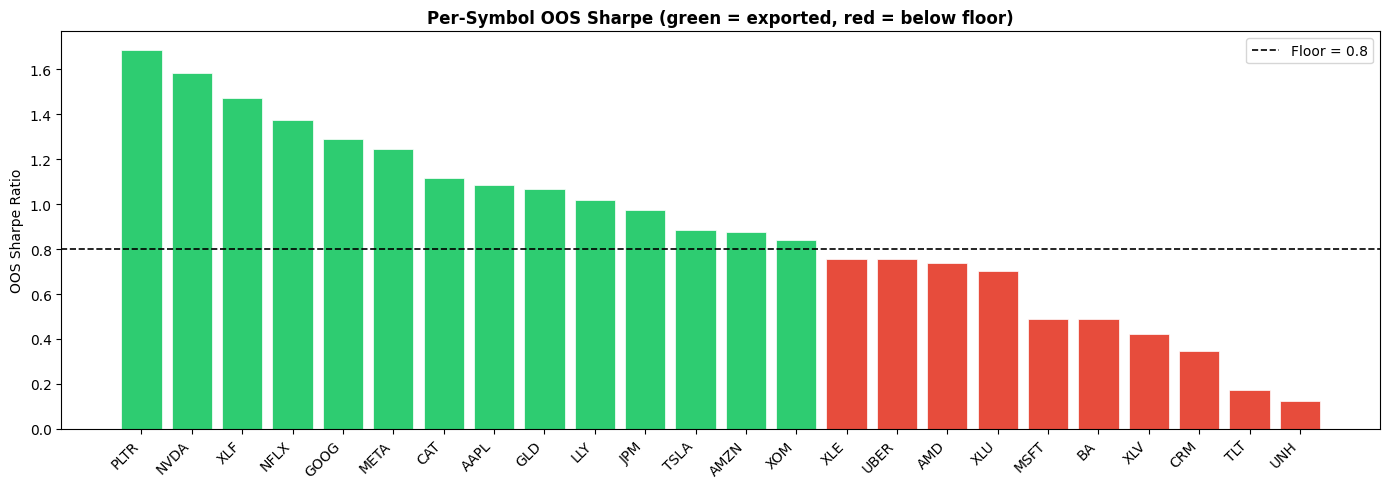

In [11]:
summary_rows = []
for ticker in WATCHLIST:
    r = results.get(ticker, {})
    summary_rows.append({
        "Ticker":    ticker,
        "Sector":    CONFIG["sector_map"].get(ticker, "?"),
        "Defensive": "✓" if ticker in DEFENSIVE else "",
        "Approach":  r.get("best_approach", "—"),
        "OOS Sharpe": f"{r['sharpe']:.3f}" if r.get("sharpe") else "—",
        "Exported":  "✓" if r.get("passes_floor") else "✗",
        "OOS rows":  r.get("oos_rows", 0),
    })

summary = pd.DataFrame(summary_rows).set_index("Ticker")
print(summary.to_string())

# Bar chart of OOS Sharpes
sharpe_vals = {k: v.get("sharpe", 0) for k, v in results.items()}
sharpe_s = pd.Series(sharpe_vals).sort_values(ascending=False)
colors = ["#2ecc71" if v >= SHARPE_FLOOR else "#e74c3c" for v in sharpe_s.values]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(sharpe_s.index, sharpe_s.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(SHARPE_FLOOR, color="black", ls="--", lw=1.2, label=f"Floor = {SHARPE_FLOOR}")
ax.set_title("Per-Symbol OOS Sharpe (green = exported, red = below floor)",
             fontweight="bold")
ax.set_ylabel("OOS Sharpe Ratio")
ax.set_xticklabels(sharpe_s.index, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(STRATEGY_DIR / "model_sharpe_summary.png", dpi=150, bbox_inches="tight")
plt.show()


## 9  Portfolio Simulation (mirrors LEAN regime-aware logic)

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Simulate the 103 strategy in Python to validate before LEAN run.
# Mirrors: regime-conditional entry, RS ranking, correlation guard,
#          trailing stop + hard stop, asymmetric min_hold, wash_sale, tax,
#          defensive rotation (GLD/TLT allowed in BEAR regime).
#
# Exit logic (in priority order):
#   1. Trailing stop  — once up ≥ trail_trigger_pct, stop at trail_pct below high
#   2. Hard stop-loss — 8% loss from entry (always active)
#   3. Max hold       — forced exit after max_hold_days
#   4. Model sell     — N consecutive sell signals; min_hold_loss_days applies
#                       only when position is at a loss (0 days required if profitable)
#
# BEAR regime: all offensive buys blocked; defensive tickers (GLD/TLT) may be
#              bought up to 1 defensive slot at 15% of portfolio.
# ─────────────────────────────────────────────────────────────────────────────

BACKTEST_START  = CONFIG["backtest_start"]
BACKTEST_END    = CONFIG["backtest_end"]
INITIAL_CASH    = CONFIG["initial_cash"]
MAX_POSITIONS   = CONFIG["max_concurrent_positions"]
CORR_THRESHOLD  = CONFIG["regime"]["correlation_guard_threshold"]
WASH_SALE_DAYS  = CONFIG.get("wash_sale_days", 30)
# Unified min_hold (asymmetric mode disabled — 5-day min caused whipsaw noise exits)
MIN_HOLD_PROFIT_DAYS = CONFIG.get("min_hold_profit_days", 20)
MIN_HOLD_LOSS_DAYS   = CONFIG.get("min_hold_loss_days",   20)

# Tax rates
ST_RATE   = CONFIG["tax"]["short_term_rate"]
LT_RATE   = CONFIG["tax"]["long_term_rate"]
LT_THRESH = CONFIG["tax"]["long_term_threshold_days"]

# Regime params per state
RP = CONFIG["regime_params"]

# Load final regime for backtest period
bt_dates = final_regime.loc[BACKTEST_START:BACKTEST_END].index

portfolio_val  = INITIAL_CASH
cash           = INITIAL_CASH
holdings       = {}     # ticker → {shares, entry_price, entry_date, high_price}
hwm            = INITIAL_CASH
skip_buys      = False
last_sell_date = {}     # ticker → last sell date (wash-sale guard)
sell_streak    = {}     # ticker → consecutive sell signal count
CONSECUTIVE_SELLS = 3   # require N consecutive sell signals before model exit

equity_curve  = []
regime_log    = []
trade_log     = []      # {action, ticker, date, pnl_pct, hold_days, tax, exit_reason}

exportable = {t for t, r in results.items() if r.get("passes_floor")}
DEFENSIVE_TICKERS     = set(CONFIG.get("defensive_tickers", ["GLD", "TLT"]))
BEAR_DEFENSIVE_PCT    = 0.15   # max position size for defensive buys in BEAR regime
BEAR_DEFENSIVE_SLOTS  = 1      # max simultaneous defensive positions in BEAR

for today in bt_dates:
    regime = final_regime.loc[today] if today in final_regime.index else "BULL_CALM"
    rp     = RP.get(regime, RP["BULL_CALM"])

    # Portfolio value (mark-to-market)
    port_val = cash
    for ticker, pos in holdings.items():
        if ticker in ohlcv and today in ohlcv[ticker].index:
            port_val += pos["shares"] * ohlcv[ticker].loc[today, "close"]
    hwm = max(hwm, port_val)

    # Drawdown circuit breaker
    if hwm > 0:
        dd = (hwm - port_val) / hwm
        skip_buys = dd >= rp["drawdown_halt_pct"]

    equity_curve.append({"date": today, "portfolio": port_val, "regime": regime})

    # ── SELLS ──────────────────────────────────────────────────────────────────
    to_sell       = []   # list of (ticker, exit_reason)
    exit_reasons  = {}

    trail_trigger_pct = rp.get("trailing_stop_trigger_pct", 0.0)
    trail_pct         = rp.get("trailing_stop_trail_pct", 0.0)

    for ticker, pos in list(holdings.items()):
        if today not in ohlcv.get(ticker, pd.DataFrame()).index:
            continue
        price     = ohlcv[ticker].loc[today, "close"]
        hold_days = (today - pos["entry_date"]).days
        loss      = (pos["entry_price"] - price) / pos["entry_price"]
        gain      = -loss  # positive when in profit

        # Update position high-water mark
        pos["high_price"] = max(pos["high_price"], price)

        # 1. Trailing stop — activates once gain ≥ trail_trigger_pct from entry
        #    OR the position previously crossed the trigger (high_price already locked it in)
        if trail_trigger_pct > 0 and trail_pct > 0:
            peak_gain = (pos["high_price"] - pos["entry_price"]) / pos["entry_price"]
            if peak_gain >= trail_trigger_pct:
                trail_stop_price = pos["high_price"] * (1 - trail_pct)
                if price <= trail_stop_price:
                    to_sell.append(ticker)
                    exit_reasons[ticker] = "trailing_stop"
                    continue

        # 2. Hard stop-loss (from entry price)
        if loss >= rp["stop_loss_pct"]:
            to_sell.append(ticker)
            exit_reasons[ticker] = "stop_loss"
            continue

        # 3. Max hold
        if hold_days >= rp["max_hold_days"]:
            to_sell.append(ticker)
            exit_reasons[ticker] = "max_hold"
            continue

        # 4. Model sell signal — asymmetric min_hold:
        #    - At loss: must hold at least MIN_HOLD_LOSS_DAYS before model exit allowed
        #    - At profit: no hold constraint (exit immediately on signal)
        min_hold_required = MIN_HOLD_PROFIT_DAYS if gain > 0 else MIN_HOLD_LOSS_DAYS
        if hold_days < min_hold_required:
            continue
        if ticker in results and results[ticker].get("oos_signals") is not None:
            sig = results[ticker]["oos_signals"]
            if today in sig.index and sig.loc[today] == -1:
                sell_streak[ticker] = sell_streak.get(ticker, 0) + 1
                if sell_streak[ticker] >= CONSECUTIVE_SELLS:
                    to_sell.append(ticker)
                    exit_reasons[ticker] = "model_sell"
            else:
                sell_streak[ticker] = 0

    for ticker in to_sell:
        pos      = holdings.pop(ticker)
        if today not in ohlcv.get(ticker, pd.DataFrame()).index:
            continue
        price     = ohlcv[ticker].loc[today, "close"]
        proceeds  = pos["shares"] * price
        cost      = pos["shares"] * pos["entry_price"]
        gain      = proceeds - cost
        hold_days = (today - pos["entry_date"]).days
        if gain > 0:
            tax_rate = LT_RATE if hold_days >= LT_THRESH else ST_RATE
            tax      = gain * tax_rate
        else:
            tax = 0.0
        cash += proceeds - tax
        pnl_pct = (price - pos["entry_price"]) / pos["entry_price"]
        last_sell_date[ticker] = today
        sell_streak[ticker]    = 0
        trade_log.append({"action": "sell", "ticker": ticker, "date": today,
                          "pnl_pct": pnl_pct, "hold_days": hold_days, "tax": tax,
                          "exit_reason": exit_reasons.get(ticker, "unknown")})

    # ── BUYS ───────────────────────────────────────────────────────────────────
    # In BEAR regime: block offensive buys but allow up to BEAR_DEFENSIVE_SLOTS defensive positions
    defensive_held = sum(1 for t in holdings if t in DEFENSIVE_TICKERS)
    if regime == "BEAR":
        if skip_buys or defensive_held >= BEAR_DEFENSIVE_SLOTS:
            regime_log.append({"date": today, "regime": regime, "positions": len(holdings)})
            continue
        # Defensive-only buy: scan GLD/TLT, pick best RS score, one slot
        def_candidates = []
        for ticker in DEFENSIVE_TICKERS & exportable:
            if ticker in holdings or today not in ohlcv.get(ticker, pd.DataFrame()).index:
                continue
            if ticker not in results or results[ticker].get("oos_signals") is None:
                continue
            last_s = last_sell_date.get(ticker)
            if last_s and (today - last_s).days < WASH_SALE_DAYS:
                continue
            sig = results[ticker]["oos_signals"]
            if today not in sig.index or sig.loc[today] != 1:
                continue
            model_score = results[ticker]["sharpe"]
            def_candidates.append((ticker, model_score))
        if def_candidates:
            def_candidates.sort(key=lambda x: x[1], reverse=True)
            ticker = def_candidates[0][0]
            invest = min(cash, port_val * BEAR_DEFENSIVE_PCT)
            if invest >= 100:
                price  = ohlcv[ticker].loc[today, "close"]
                shares = invest / price
                cash  -= invest
                holdings[ticker] = {
                    "shares": shares, "entry_price": price,
                    "entry_date": today, "high_price": price,
                }
                sell_streak[ticker] = 0
                trade_log.append({"action": "buy", "ticker": ticker, "date": today,
                                   "price": price, "shares": shares, "invest": invest,
                                   "regime": "BEAR_defensive"})
        regime_log.append({"date": today, "regime": regime, "positions": len(holdings)})
        continue

    if skip_buys or len(holdings) >= MAX_POSITIONS:
        regime_log.append({"date": today, "regime": regime, "positions": len(holdings)})
        continue

    open_slots  = MAX_POSITIONS - len(holdings)
    max_pos_pct = rp.get("max_position_pct", 0.30)

    candidates = []
    for ticker in exportable:
        if ticker in holdings or today not in ohlcv.get(ticker, pd.DataFrame()).index:
            continue
        if ticker not in results or results[ticker].get("oos_signals") is None:
            continue
        # Wash-sale guard
        last_s = last_sell_date.get(ticker)
        if last_s and (today - last_s).days < WASH_SALE_DAYS:
            continue
        sig = results[ticker]["oos_signals"]
        if today not in sig.index or sig.loc[today] != 1:
            continue

        # Relative-strength score vs sector ETF
        sector   = CONFIG["sector_map"].get(ticker, "other")
        etf      = SECTOR_ETF.get(sector)
        rs_score = 0.0
        if etf and etf in ohlcv:
            try:
                stock_ret = ohlcv[ticker]["close"].pct_change(20).loc[today]
                etf_ret   = ohlcv[etf]["close"].pct_change(20).loc[today]
                rs_score  = float(stock_ret - etf_ret) if not (np.isnan(stock_ret) or np.isnan(etf_ret)) else 0.0
            except Exception:
                pass

        model_score = results[ticker]["sharpe"]
        candidates.append((ticker, model_score, rs_score))

    if not candidates:
        continue

    # Rank: 50% model score + 50% relative strength
    if len(candidates) > 1:
        ms  = [c[1] for c in candidates]; rs = [c[2] for c in candidates]
        ms_range = max(ms) - min(ms) or 1; rs_range = max(rs) - min(rs) or 1
        candidates.sort(
            key=lambda c: 0.5 * (c[1] - min(ms)) / ms_range + 0.5 * (c[2] - min(rs)) / rs_range,
            reverse=True)

    selected = []
    for ticker, ms, rs in candidates:
        if len(selected) >= open_slots:
            break
        # Correlation guard
        corr_ok = True
        for held in list(holdings.keys()) + selected:
            corr = corr_dict.get(ticker, {}).get(held, corr_dict.get(held, {}).get(ticker, 0))
            if abs(corr) >= CORR_THRESHOLD:
                corr_ok = False
                break
        if not corr_ok:
            continue
        selected.append(ticker)

    for ticker in selected:
        invest = min(cash, port_val * max_pos_pct)
        if invest < 100:
            continue
        price  = ohlcv[ticker].loc[today, "close"]
        shares = invest / price
        cash  -= invest
        holdings[ticker] = {
            "shares":      shares,
            "entry_price": price,
            "entry_date":  today,
            "high_price":  price,   # track for trailing stop
        }
        sell_streak[ticker] = 0
        trade_log.append({"action": "buy", "ticker": ticker, "date": today,
                          "price": price, "shares": shares, "invest": invest})

equity_df = pd.DataFrame(equity_curve).set_index("date")
final_val = equity_df["portfolio"].iloc[-1]
total_ret = final_val / INITIAL_CASH - 1

# Summary
buys  = [t for t in trade_log if t["action"] == "buy"]
sells = [t for t in trade_log if t["action"] == "sell"]
wins  = [t for t in sells if t["pnl_pct"] > 0]
n_years = len(equity_df) / 252
apy = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else 0
print(f"Simulation complete: {len(equity_df)} days")
print(f"Final value: ${final_val:,.0f}  |  Return: {total_ret:.1%}  |  APY: {apy:.1%}")
print(f"Trades: {len(buys)} buys, {len(sells)} sells  |  Win rate: {len(wins)/max(1,len(sells)):.0%}")
if sells:
    avg_hold  = sum(t["hold_days"] for t in sells) / len(sells)
    avg_pnl   = sum(t["pnl_pct"]  for t in sells) / len(sells)
    total_tax = sum(t["tax"]       for t in sells)
    from collections import Counter
    reasons = Counter(t.get("exit_reason","?") for t in sells)
    print(f"Avg hold: {avg_hold:.0f}d  |  Avg P&L/trade: {avg_pnl:.1%}  |  Total tax: ${total_tax:,.0f}")
    print(f"Exit reasons: {dict(reasons)}")


Simulation complete: 560 days
Final value: $132,413  |  Return: 32.4%  |  APY: 13.5%
Trades: 76 buys, 68 sells  |  Win rate: 40%
Avg hold: 76d  |  Avg P&L/trade: 5.9%  |  Total tax: $42,167
Exit reasons: {'stop_loss': 38, 'model_sell': 18, 'trailing_stop': 11, 'max_hold': 1}


## 10  Portfolio Performance Charts

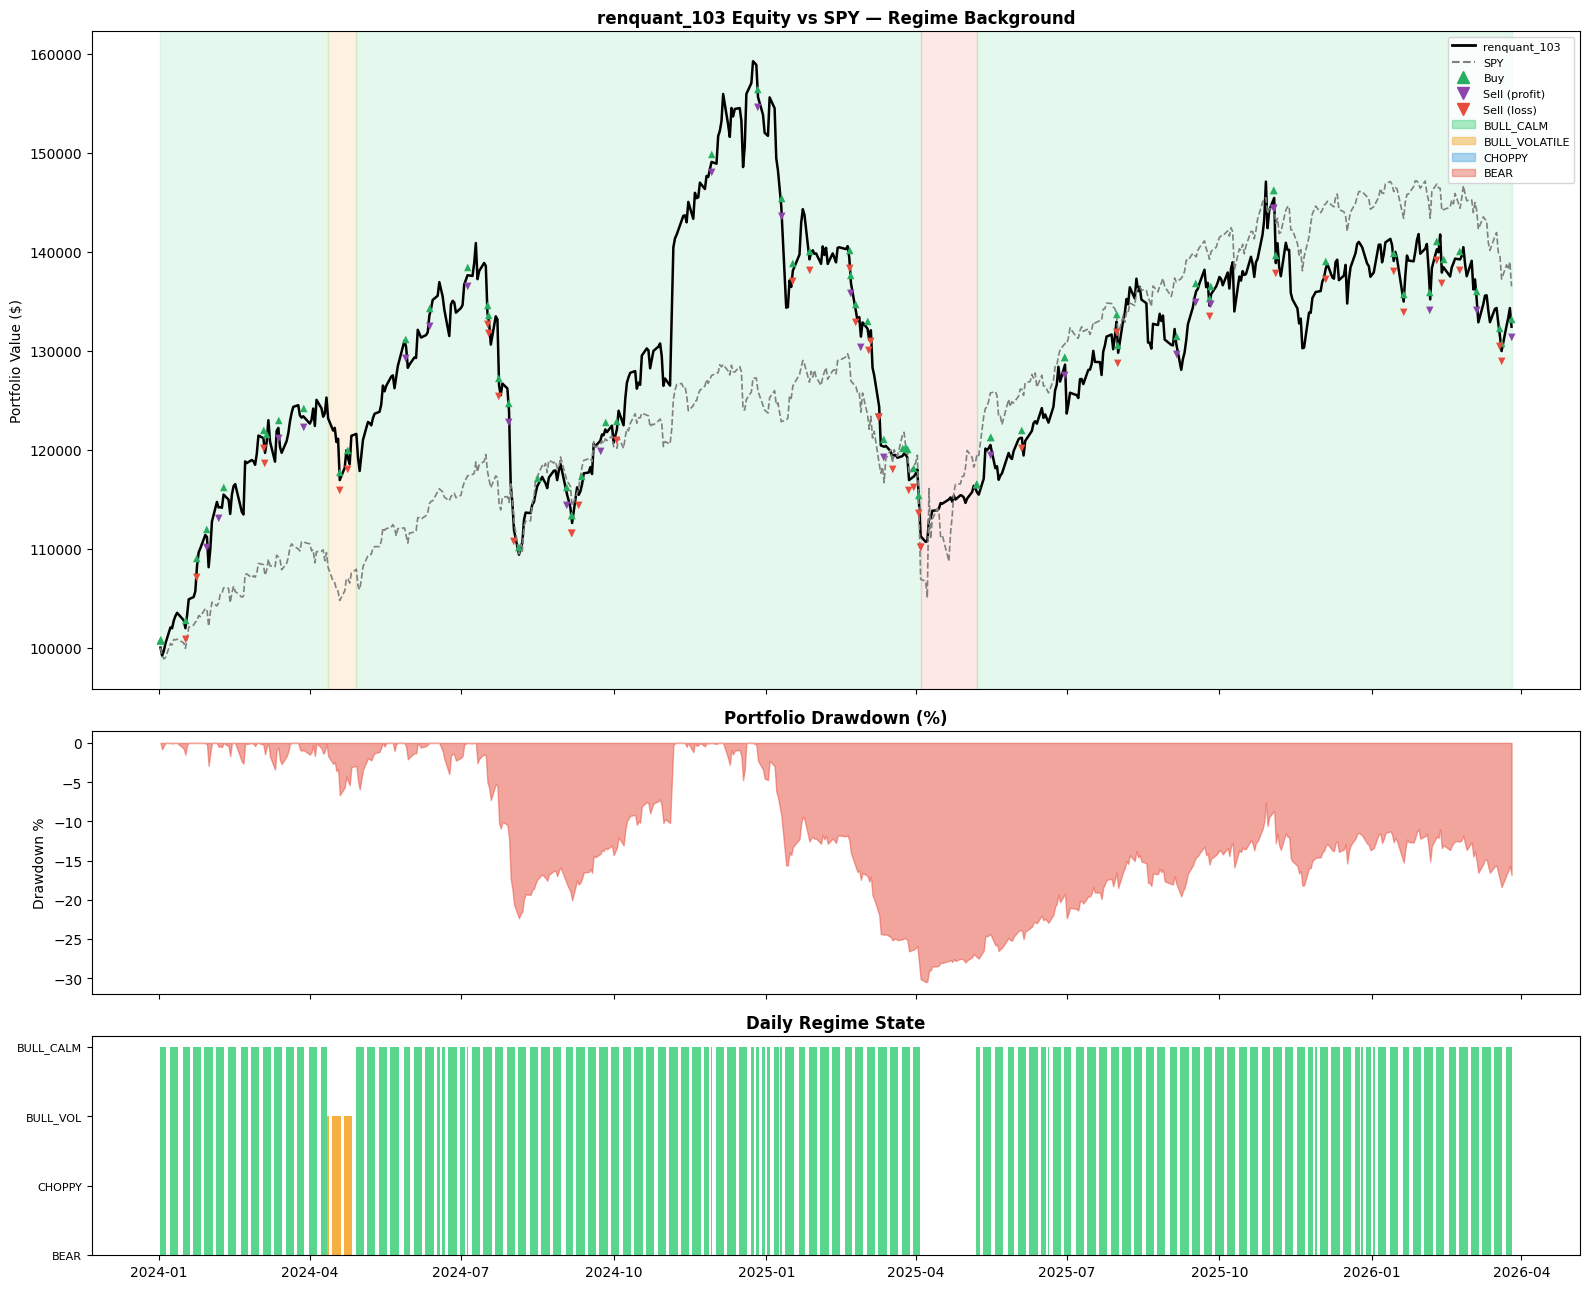

In [13]:
# SPY benchmark
spy_bt = spy_df["close"].loc[BACKTEST_START:BACKTEST_END]
spy_norm = spy_bt / spy_bt.iloc[0] * INITIAL_CASH

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1.2, 1]})

# ── Panel 1: Equity curve with regime background ──
ax = axes[0]
port_norm = equity_df["portfolio"]

# Shade by regime
prev_r = None; start_d = None
for d in equity_df.index:
    r = equity_df.loc[d, "regime"]
    if r != prev_r:
        if prev_r:
            ax.axvspan(start_d, d, alpha=0.12, color=REGIME_COLORS.get(prev_r, "grey"))
        prev_r  = r; start_d = d
if prev_r:
    ax.axvspan(start_d, equity_df.index[-1], alpha=0.12, color=REGIME_COLORS.get(prev_r, "grey"))

ax.plot(port_norm.index, port_norm.values, color="black", lw=1.8, label="renquant_103")
ax.plot(spy_norm.index,  spy_norm.values,  color="grey",  lw=1.2, ls="--", label="SPY")

# ── Buy/sell markers ──
buy_trades  = [t for t in trade_log if t["action"] == "buy"  and t["date"] in port_norm.index]
sell_trades = [t for t in trade_log if t["action"] == "sell" and t["date"] in port_norm.index]
for t in buy_trades:
    ax.annotate("▲", xy=(t["date"], port_norm.loc[t["date"]]),
                fontsize=7, color="#27ae60", ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points")
for t in sell_trades:
    pnl = t.get("pnl_pct", 0)
    color = "#e74c3c" if pnl < 0 else "#8e44ad"
    ax.annotate("▼", xy=(t["date"], port_norm.loc[t["date"]]),
                fontsize=7, color=color, ha="center", va="top",
                xytext=(0, -3), textcoords="offset points")

patches = [mpatches.Patch(color=c, alpha=0.4, label=r) for r, c in REGIME_COLORS.items()]
ax.legend(handles=[
    plt.Line2D([0],[0],color="black",lw=2,label="renquant_103"),
    plt.Line2D([0],[0],color="grey",lw=1.5,ls="--",label="SPY"),
    plt.Line2D([0],[0],marker="^",color="#27ae60",lw=0,markersize=8,label="Buy"),
    plt.Line2D([0],[0],marker="v",color="#8e44ad",lw=0,markersize=8,label="Sell (profit)"),
    plt.Line2D([0],[0],marker="v",color="#e74c3c",lw=0,markersize=8,label="Sell (loss)"),
] + patches, fontsize=8)
ax.set_title("renquant_103 Equity vs SPY — Regime Background", fontweight="bold")
ax.set_ylabel("Portfolio Value ($)")

# ── Panel 2: Drawdown ──
ax = axes[1]
roll_max = port_norm.cummax()
drawdown = (port_norm - roll_max) / roll_max * 100
ax.fill_between(drawdown.index, drawdown.values, 0, color="#e74c3c", alpha=0.5)
ax.set_title("Portfolio Drawdown (%)", fontweight="bold")
ax.set_ylabel("Drawdown %")

# ── Panel 3: Regime state ──
ax = axes[2]
regime_numeric = {BULL_CALM: 3, BULL_VOLATILE: 2, CHOPPY: 1, BEAR: 0}
regime_vals    = equity_df["regime"].map(regime_numeric).fillna(-1)
colors_seq     = equity_df["regime"].map(REGIME_COLORS).fillna("grey")

ax.bar(regime_vals.index, regime_vals.values,
       color=colors_seq.values, width=1, alpha=0.8)
ax.set_yticks([0,1,2,3])
ax.set_yticklabels(["BEAR","CHOPPY","BULL_VOL","BULL_CALM"], fontsize=8)
ax.set_title("Daily Regime State", fontweight="bold")

plt.tight_layout()
plt.savefig(STRATEGY_DIR / "portfolio_simulation.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# ── Performance statistics ──

def calc_stats(series):
    """Compute standard performance metrics from an equity series."""
    series = series.dropna()
    daily_ret = series.pct_change().dropna()
    n_years = len(daily_ret) / 252
    total_return = series.iloc[-1] / series.iloc[0] - 1
    cagr = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0
    sharpe = float(daily_ret.mean() / daily_ret.std() * np.sqrt(252)) if daily_ret.std() > 0 else 0
    roll_max = series.cummax()
    max_dd = float(((series - roll_max) / roll_max).min())
    volatility = float(daily_ret.std() * np.sqrt(252))
    return {"total_return": total_return, "cagr": cagr, "sharpe": sharpe,
            "max_drawdown": max_dd, "volatility": volatility}

stats     = calc_stats(equity_df["portfolio"])
spy_stats = calc_stats(spy_norm)

print("=" * 45)
print(f"{'Metric':<25} {'103':>8}  {'SPY':>8}")
print("=" * 45)
# Add APY to stats dict (same formula as CAGR but labeled for clarity)
stats["apy"]     = stats["cagr"]
spy_stats["apy"] = spy_stats["cagr"]

for k in ["total_return", "apy", "sharpe", "max_drawdown", "volatility"]:
    v103 = stats.get(k, 0)
    vspy = spy_stats.get(k, 0)
    if k in ("total_return", "apy", "max_drawdown", "volatility"):
        print(f"{k:<25} {v103:>7.1%}  {vspy:>7.1%}")
    else:
        print(f"{k:<25} {v103:>8.3f}  {vspy:>8.3f}")
print("=" * 45)

# Regime breakdown
print("\nRegime days:")
for r, c in REGIME_COLORS.items():
    n = (equity_df["regime"] == r).sum()
    pct = n / len(equity_df)
    print(f"  {r:<16} {n:>4}d  {pct:.1%}")

Metric                         103       SPY
total_return                32.4%    36.5%
apy                         13.5%    15.1%
sharpe                       0.702     0.952
max_drawdown               -30.5%   -19.0%
volatility                  21.3%    16.1%

Regime days:
  BULL_CALM         526d  93.9%
  BULL_VOLATILE      11d  2.0%
  CHOPPY              0d  0.0%
  BEAR               23d  4.1%


## 10b  Trade Log & Detailed Analysis

In [15]:
# ── All trades table ──
import pandas as pd

if trade_log:
    tdf = pd.DataFrame(trade_log)
    tdf["date"] = pd.to_datetime(tdf["date"])

    # Buys
    buys_df = tdf[tdf["action"] == "buy"][["date","ticker","price","shares","invest"]].copy()
    buys_df = buys_df.rename(columns={"price":"entry_price","shares":"qty","invest":"invested"})
    buys_df["invested"] = buys_df["invested"].map("${:,.0f}".format)
    buys_df["entry_price"] = buys_df["entry_price"].map("${:.2f}".format)
    buys_df["qty"] = buys_df["qty"].map("{:.2f}".format)
    buys_df["date"] = buys_df["date"].dt.date

    # Sells
    sells_df = tdf[tdf["action"] == "sell"][["date","ticker","pnl_pct","hold_days","tax"]].copy()
    sells_df["pnl_pct"] = sells_df["pnl_pct"].map("{:+.1%}".format)
    sells_df["tax"] = sells_df["tax"].map("${:,.0f}".format)
    sells_df["date"] = sells_df["date"].dt.date
    sells_df = sells_df.rename(columns={"date":"sell_date","pnl_pct":"P&L","hold_days":"hold_d","tax":"tax_paid"})

    print(f"\n{'='*60}")
    print(f"  TRADE LOG — {len(buys_df)} buys, {len(sells_df)} sells")
    print(f"{'='*60}")
    print("\nBUYS:")
    print(buys_df.to_string(index=False))
    print("\nSELLS:")
    print(sells_df.to_string(index=False))
else:
    print("No trades recorded.")



  TRADE LOG — 76 buys, 68 sells

BUYS:
      date ticker entry_price    qty invested
2024-01-02   NVDA      $48.17 311.41  $15,000
2024-01-02    CAT     $292.71  51.25  $15,000
2024-01-02   META     $346.29  43.32  $15,000
2024-01-02    XLF      $37.76 397.25  $15,000
2024-01-02   NFLX      $46.85 320.17  $15,000
2024-01-02    GLD     $190.72  78.65  $15,000
2024-01-02    XOM     $102.36  97.69  $10,000
2024-01-17   GOOG     $142.89  66.31   $9,474
2024-01-24    LLY     $633.70  23.13  $14,660
2024-01-30   AMZN     $159.00 101.66  $16,165
2024-02-09   TSLA     $193.57  84.72  $16,399
2024-03-04   META     $498.19  17.86   $8,898
2024-03-06    XOM     $106.77 143.41  $15,312
2024-03-13   NFLX      $60.94 264.11  $16,096
2024-03-28    GLD     $205.72  83.86  $17,251
2024-04-19   GOOG     $155.72  94.14  $14,659
2024-04-24   AAPL     $169.02  52.15   $8,814
2024-05-29   NFLX      $65.46 270.22  $17,689
2024-06-12   META     $508.84  30.68  $15,610
2024-07-05    LLY     $914.57  19.87  $1

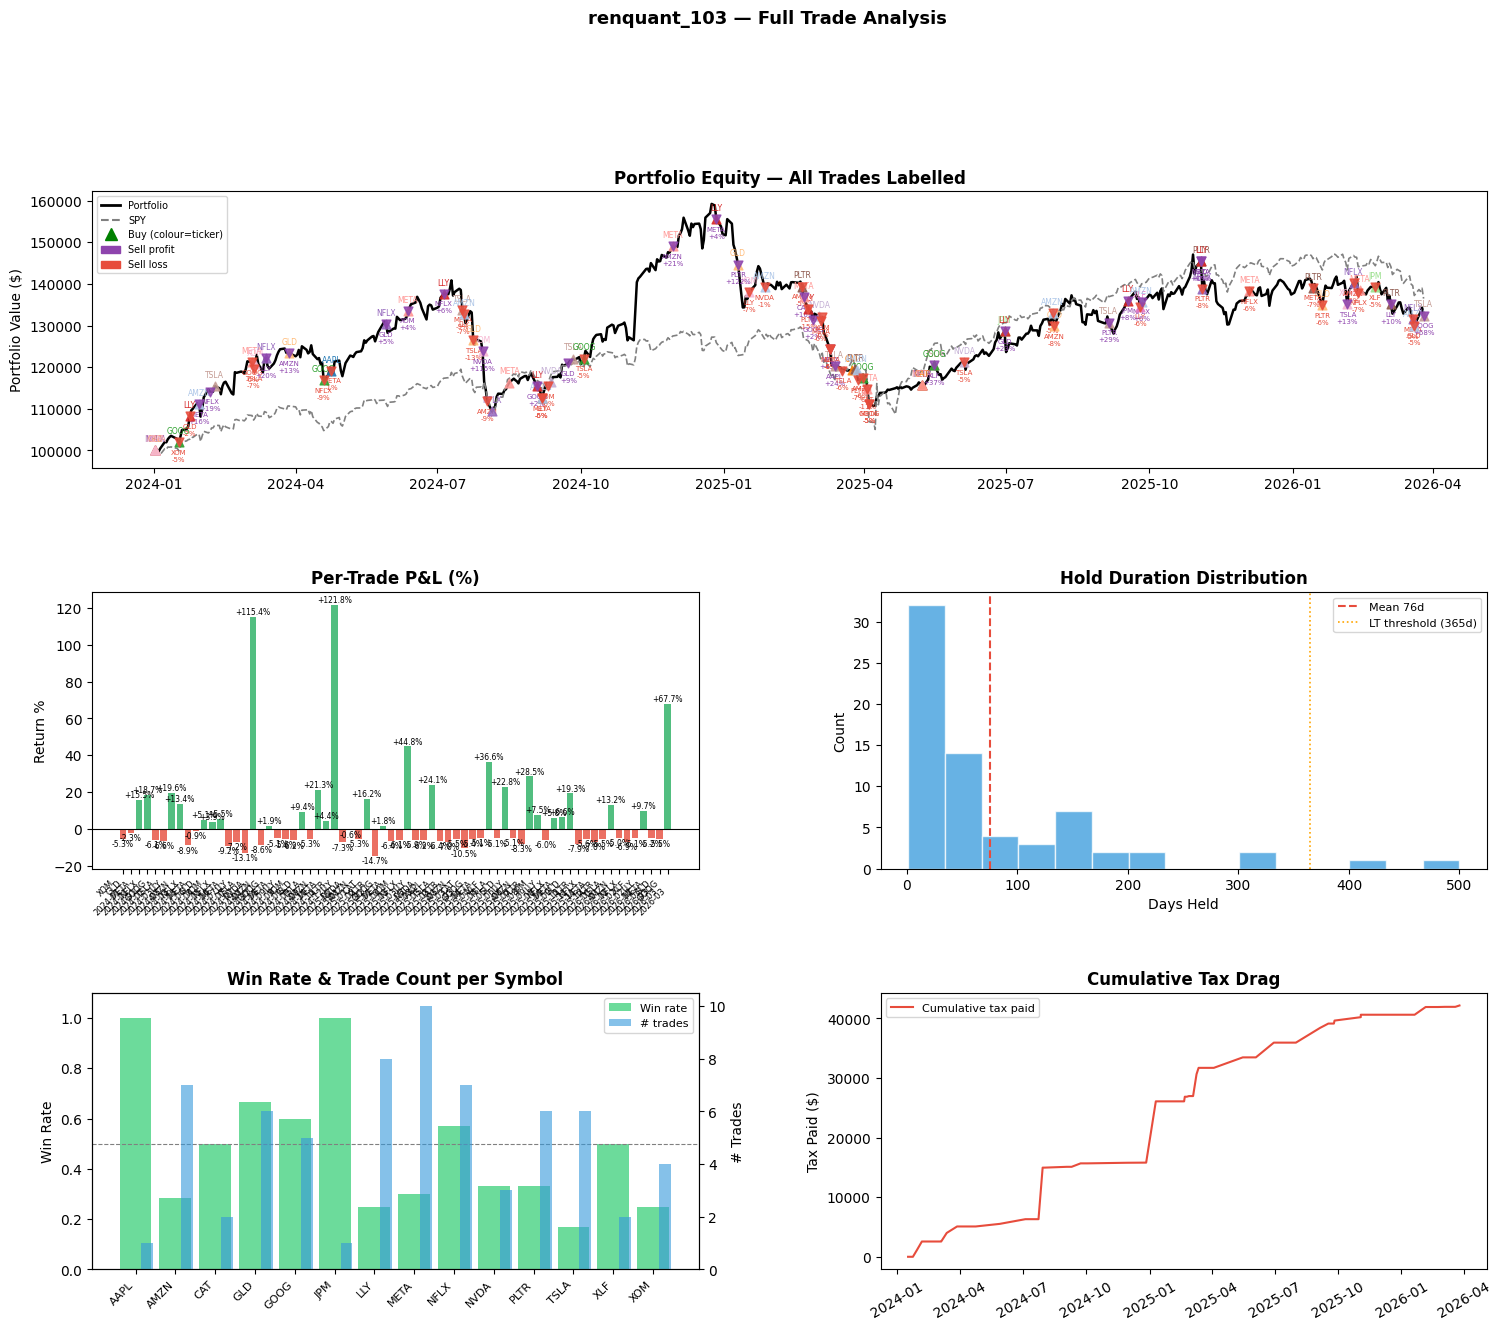

Saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/trade_analysis.png


In [16]:
# ── Detailed trade chart: per-symbol equity + P&L bars + hold durations ──
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

sells = [t for t in trade_log if t["action"] == "sell"]
buys  = [t for t in trade_log if t["action"] == "buy"]

if not sells and not buys:
    print("No trades to chart.")
else:
    tickers_traded = sorted(set([t["ticker"] for t in buys + sells]))
    colors_t = plt.cm.tab20.colors

    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

    # ── Panel (0,0): Portfolio equity with per-ticker labeled buy/sell markers ──
    ax0 = fig.add_subplot(gs[0, :])
    ax0.plot(equity_df.index, equity_df["portfolio"], color="black", lw=1.8, label="Portfolio")
    ax0.plot(spy_norm.index, spy_norm.values, color="grey", lw=1.2, ls="--", label="SPY")

    ticker_colors = {t: colors_t[i % 20] for i, t in enumerate(tickers_traded)}
    for trade in buys:
        d = trade["date"]
        if d in equity_df.index:
            c = ticker_colors.get(trade["ticker"], "green")
            ax0.scatter(d, equity_df.loc[d, "portfolio"], marker="^", color=c,
                        s=40, zorder=5, alpha=0.85)
            ax0.annotate(trade["ticker"], xy=(d, equity_df.loc[d, "portfolio"]),
                         fontsize=5.5, color=c, ha="center", va="bottom",
                         xytext=(0, 5), textcoords="offset points")
    for trade in sells:
        d = trade["date"]
        if d in equity_df.index:
            c = "#e74c3c" if trade["pnl_pct"] < 0 else "#8e44ad"
            ax0.scatter(d, equity_df.loc[d, "portfolio"], marker="v", color=c,
                        s=40, zorder=5, alpha=0.85)
            ax0.annotate(f"{trade['ticker']}\n{trade['pnl_pct']:+.0%}",
                         xy=(d, equity_df.loc[d, "portfolio"]),
                         fontsize=5, color=c, ha="center", va="top",
                         xytext=(0, -5), textcoords="offset points")

    legend_handles = [
        plt.Line2D([0],[0],color="black",lw=2,label="Portfolio"),
        plt.Line2D([0],[0],color="grey",lw=1.5,ls="--",label="SPY"),
        plt.Line2D([0],[0],marker="^",color="green",lw=0,markersize=8,label="Buy (colour=ticker)"),
        mpatches.Patch(color="#8e44ad",label="Sell profit"),
        mpatches.Patch(color="#e74c3c",label="Sell loss"),
    ]
    ax0.legend(handles=legend_handles, fontsize=7, loc="upper left")
    ax0.set_title("Portfolio Equity — All Trades Labelled", fontweight="bold")
    ax0.set_ylabel("Portfolio Value ($)")

    # ── Panel (1,0): Per-trade P&L bar chart ──
    ax1 = fig.add_subplot(gs[1, 0])
    if sells:
        sells_sorted = sorted(sells, key=lambda x: x["date"])
        labels = [f"{t['ticker']}\n{str(t['date'])[:7]}" for t in sells_sorted]
        pnls   = [t["pnl_pct"] * 100 for t in sells_sorted]
        colors_bar = ["#e74c3c" if p < 0 else "#27ae60" for p in pnls]
        bars = ax1.bar(range(len(pnls)), pnls, color=colors_bar, alpha=0.8)
        ax1.set_xticks(range(len(pnls)))
        ax1.set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
        ax1.axhline(0, color="black", lw=0.8)
        ax1.set_title("Per-Trade P&L (%)", fontweight="bold")
        ax1.set_ylabel("Return %")
        for bar, pnl in zip(bars, pnls):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.3 if pnl >= 0 else -0.3),
                     f"{pnl:+.1f}%", ha="center", va="bottom" if pnl >= 0 else "top", fontsize=5.5)
    else:
        ax1.text(0.5, 0.5, "No completed trades", ha="center", va="center")

    # ── Panel (1,1): Hold duration histogram ──
    ax2 = fig.add_subplot(gs[1, 1])
    if sells:
        hold_days = [t["hold_days"] for t in sells]
        ax2.hist(hold_days, bins=15, color="#3498db", alpha=0.75, edgecolor="white")
        ax2.axvline(np.mean(hold_days), color="#e74c3c", lw=1.5, ls="--",
                    label=f"Mean {np.mean(hold_days):.0f}d")
        ax2.axvline(365, color="orange", lw=1.2, ls=":", label="LT threshold (365d)")
        ax2.legend(fontsize=8)
        ax2.set_title("Hold Duration Distribution", fontweight="bold")
        ax2.set_xlabel("Days Held")
        ax2.set_ylabel("Count")
    else:
        ax2.text(0.5, 0.5, "No completed trades", ha="center", va="center")

    # ── Panel (2,0): Per-symbol trade count & win rate ──
    ax3 = fig.add_subplot(gs[2, 0])
    if sells:
        sym_data = {}
        for t in sells:
            sym_data.setdefault(t["ticker"], {"wins":0,"total":0})
            sym_data[t["ticker"]]["total"] += 1
            if t["pnl_pct"] > 0:
                sym_data[t["ticker"]]["wins"] += 1
        syms = sorted(sym_data)
        win_rates = [sym_data[s]["wins"] / sym_data[s]["total"] for s in syms]
        counts    = [sym_data[s]["total"] for s in syms]
        x = range(len(syms))
        ax3.bar(x, win_rates, color="#2ecc71", alpha=0.7, label="Win rate")
        ax3_r = ax3.twinx()
        ax3_r.bar([i + 0.3 for i in x], counts, width=0.3, color="#3498db", alpha=0.6, label="# trades")
        ax3.set_xticks(x); ax3.set_xticklabels(syms, rotation=45, ha="right", fontsize=8)
        ax3.set_ylim(0, 1.1); ax3.axhline(0.5, color="grey", lw=0.8, ls="--")
        ax3.set_title("Win Rate & Trade Count per Symbol", fontweight="bold")
        ax3.set_ylabel("Win Rate")
        ax3_r.set_ylabel("# Trades")
        lines1, labels1 = ax3.get_legend_handles_labels()
        lines2, labels2 = ax3_r.get_legend_handles_labels()
        ax3.legend(lines1+lines2, labels1+labels2, fontsize=8)

    # ── Panel (2,1): Cumulative tax paid vs gross P&L ──
    ax4 = fig.add_subplot(gs[2, 1])
    if sells:
        sells_sorted = sorted(sells, key=lambda x: x["date"])
        dates        = [t["date"] for t in sells_sorted]
        cum_tax      = np.cumsum([t["tax"] for t in sells_sorted])
        cum_gross_pnl = np.cumsum([t["pnl_pct"] * INITIAL_CASH / max(1, len(sells_sorted))
                                   for t in sells_sorted])
        ax4.plot(dates, cum_tax, color="#e74c3c", lw=1.5, label="Cumulative tax paid")
        ax4.set_title("Cumulative Tax Drag", fontweight="bold")
        ax4.set_ylabel("Tax Paid ($)")
        ax4.legend(fontsize=8)
        ax4.tick_params(axis="x", rotation=30)

    plt.suptitle("renquant_103 — Full Trade Analysis", fontsize=13, fontweight="bold", y=1.01)
    plt.savefig(STRATEGY_DIR / "trade_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {STRATEGY_DIR / 'trade_analysis.png'}")


## 11  Per-Symbol OOS Equity Curves

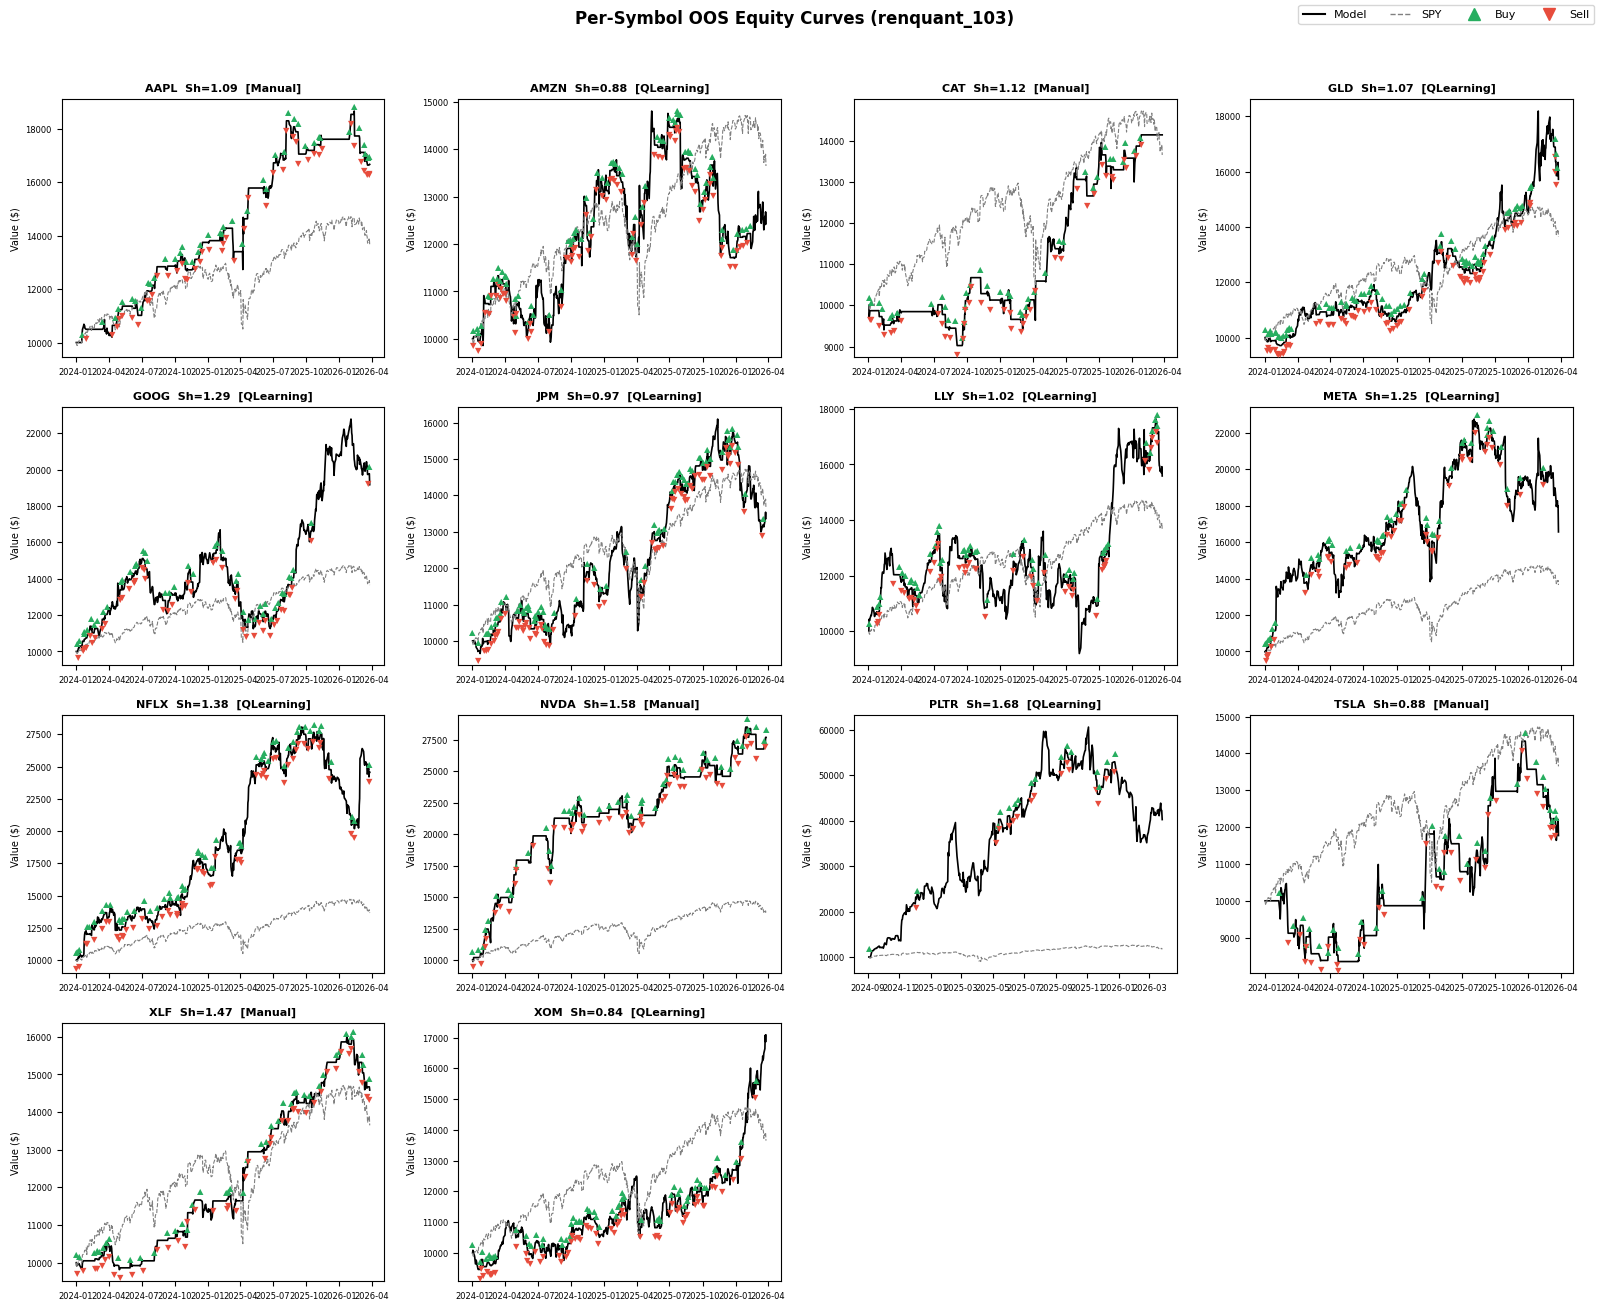

In [17]:
pass_tickers = sorted([t for t, r in results.items() if r.get("passes_floor")])

# Also include bootstrapped models that exist on disk
import json as _json
from pathlib import Path as _Path
model_dir = STRATEGY_DIR / "models"
for ticker in WATCHLIST:
    if ticker in pass_tickers:
        continue
    meta = model_dir / ticker / f"{ticker}-policy-metadata.json"
    if meta.exists():
        with meta.open() as _f:
            _m = _json.load(_f)
        if ticker not in results:
            results[ticker] = {
                "sharpe": _m.get("sharpe", 0),
                "best_approach": _m.get("best_approach", "bootstrapped"),
                "passes_floor": True,
                "oos_signals": None,
                "oos_prices": ohlcv.get(ticker, pd.DataFrame())["close"] if ticker in ohlcv else pd.Series(),
                "oos_rows": 0,
            }
            pass_tickers.append(ticker)

pass_tickers = sorted(set(pass_tickers))

if not pass_tickers:
    print("No models available — run Section 5 (training) first.")
else:
    ncols = 4
    nrows = max(1, (len(pass_tickers) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2))
    axes = np.array(axes).flatten()

    spy_oos_close = spy_df["close"].loc[BACKTEST_START:BACKTEST_END]

    for i, ticker in enumerate(pass_tickers):
        ax     = axes[i]
        r      = results[ticker]
        sigs   = r["oos_signals"]
        prices = r["oos_prices"].loc[BACKTEST_START:BACKTEST_END]

        if sigs is None or prices.empty:
            ax.set_title(f"{ticker} — no OOS data", fontsize=8); continue

        sigs_bt = sigs.reindex(prices.index).fillna(0)
        try:
            pos       = sigs_bt.clip(0, 1).shift(1).fillna(0)
            strat_ret = prices.pct_change().fillna(0) * pos
            pv        = 10_000 * (1 + strat_ret).cumprod()
            spy_sub   = spy_oos_close.reindex(prices.index)
            spy_sub   = spy_sub / spy_sub.iloc[0] * 10_000

            ax.plot(pv.index,      pv.values,      color="black", lw=1.2, label="Model")
            ax.plot(spy_sub.index, spy_sub.values, color="grey",  lw=0.8, ls="--", label="SPY")

            # Buy/sell markers from signal transitions
            prev_sig = 0.0
            for dt in pv.index:
                cur_sig = float(sigs_bt.loc[dt]) if dt in sigs_bt.index else 0.0
                pv_val  = float(pv.loc[dt])
                if prev_sig != 1.0 and cur_sig == 1.0:   # entry
                    ax.annotate("▲", xy=(dt, pv_val), fontsize=6, color="#27ae60",
                                ha="center", va="bottom",
                                xytext=(0, 3), textcoords="offset points")
                elif prev_sig == 1.0 and cur_sig != 1.0:  # exit
                    ax.annotate("▼", xy=(dt, pv_val), fontsize=6, color="#e74c3c",
                                ha="center", va="top",
                                xytext=(0, -3), textcoords="offset points")
                prev_sig = cur_sig

            ax.set_title(f"{ticker}  Sh={r['sharpe']:.2f}  [{r['best_approach']}]",
                         fontsize=8, fontweight="bold")
            ax.set_ylabel("Value ($)", fontsize=7)
            ax.tick_params(labelsize=6)
        except Exception as e:
            ax.set_title(f"{ticker} — error: {e}", fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Shared legend
    fig.legend(handles=[
        plt.Line2D([0],[0], color="black", lw=1.5, label="Model"),
        plt.Line2D([0],[0], color="grey",  lw=1,   ls="--", label="SPY"),
        plt.Line2D([0],[0], marker="^", color="#27ae60", lw=0, markersize=8, label="Buy"),
        plt.Line2D([0],[0], marker="v", color="#e74c3c", lw=0, markersize=8, label="Sell"),
    ], loc="upper right", fontsize=8, ncol=4)

    plt.suptitle("Per-Symbol OOS Equity Curves (renquant_103)", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(STRATEGY_DIR / "per_symbol_oos.png", dpi=150, bbox_inches="tight")
    plt.show()


## 12  Fetch Earnings Calendar (run once)

In [18]:
# Run this cell to refresh the earnings calendar artifact.
# Can also run: python scripts/fetch_earnings_calendar.py --strategy renquant_103

import subprocess, sys
result = subprocess.run(
    [sys.executable, str(ROOT / "scripts" / "fetch_earnings_calendar.py"),
     "--strategy", STRATEGY, "--lookahead", "90"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Fetching earnings calendar for 24 symbols → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/earnings-calendar.json
  TSLA... 1 dates
  AMZN... 1 dates
  GOOG... 1 dates
  MSFT... 1 dates
  AMD... 1 dates
  NFLX... 1 dates
  CRM... 1 dates
  PLTR... 1 dates
  UBER... 1 dates
  NVDA... 1 dates
  META... 1 dates
  AAPL... 1 dates
  JPM... 1 dates
  UNH... 1 dates
  XOM... 1 dates
  CAT... 1 dates
  BA... 1 dates
  XLE... 0 dates
  XLF... 0 dates
  LLY... 1 dates
  GLD... 0 dates
  TLT... 0 dates
  XLV... 0 dates
  XLU... 0 dates

Saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/earnings-calendar.json



## Done

Next steps:
1. Review regime charts (Section 3) — do the regime transitions make intuitive sense?
2. Check per-symbol Sharpe table (Section 8) — any symbols you want to add/remove?
3. Export LEAN data: `python scripts/export_lean_watchlist.py --strategy renquant_103`
4. Run LEAN backtest: `cd backtesting/renquant_103 && lean backtest .`
5. Analyse: `python scripts/analyze_backtest.py --strategy renquant_103`